In [2]:
dbda_programs = "../DBDA2Eprograms/"
src = function(name) {
    source(paste0(dbda_programs, name, ".R"))
}

In [4]:
src("DBDA2E-utilities")
src("BernBeta")


*********************************************************************
Kruschke, J. K. (2015). Doing Bayesian Data Analysis, Second Edition:
A Tutorial with R, JAGS, and Stan. Academic Press / Elsevier.
*********************************************************************



# DBDA Exercise 7.1

In [19]:
# Specify the data, to be used in the likelihood function.
myData = c(rep(0,6),rep(1,14))
# Specify the length of the trajectory, i.e., the number of jumps to try:
trajLength = 50000 # arbitrary large number
# Initialize the vector that will store the results:
trajectory = rep( 0 , trajLength )
# Specify where to start the trajectory:
trajectory[1] = 0.01 # arbitrary value
# Specify the burn-in period:
burnIn = ceiling( 0.0 * trajLength ) # arbitrary number, less than trajLength
# Initialize accepted, rejected counters, just to monitor performance:
nAccepted = 0
nRejected = 0

# Now generate the random walk. The 't' index is time or trial in the walk.
# Specify seed to reproduce same random walk:
# set.seed(47405)
# Specify standard deviation of proposal distribution:
proposalSD = c(0.02,0.2,2.0)

In [20]:
# Define the Bernoulli likelihood function, p(D|theta).
# The argument theta could be a vector, not just a scalar.
likelihood = function( theta , data ) {
  z = sum( data )
  N = length( data )
  pDataGivenTheta = theta^z * (1-theta)^(N-z)
  # The theta values passed into this function are generated at random,
  # and therefore might be inadvertently greater than 1 or less than 0.
  # The likelihood for theta > 1 or for theta < 0 is zero:
  pDataGivenTheta[ theta > 1 | theta < 0 ] = 0
  return( pDataGivenTheta )
}

In [21]:
# Define the prior density function. 
prior = function( theta ) {
  pTheta = dbeta( theta , 1 , 1 )
  # The theta values passed into this function are generated at random,
  # and therefore might be inadvertently greater than 1 or less than 0.
  # The prior for theta > 1 or for theta < 0 is zero:
  pTheta[ theta > 1 | theta < 0 ] = 0
  return( pTheta )
}

In [22]:
# Define the relative probability of the target distribution, 
# as a function of vector theta. For our application, this
# target distribution is the unnormalized posterior distribution.
targetRelProb = function( theta , data ) {
  targetRelProb =  likelihood( theta , data ) * prior( theta )
  return( targetRelProb )
}

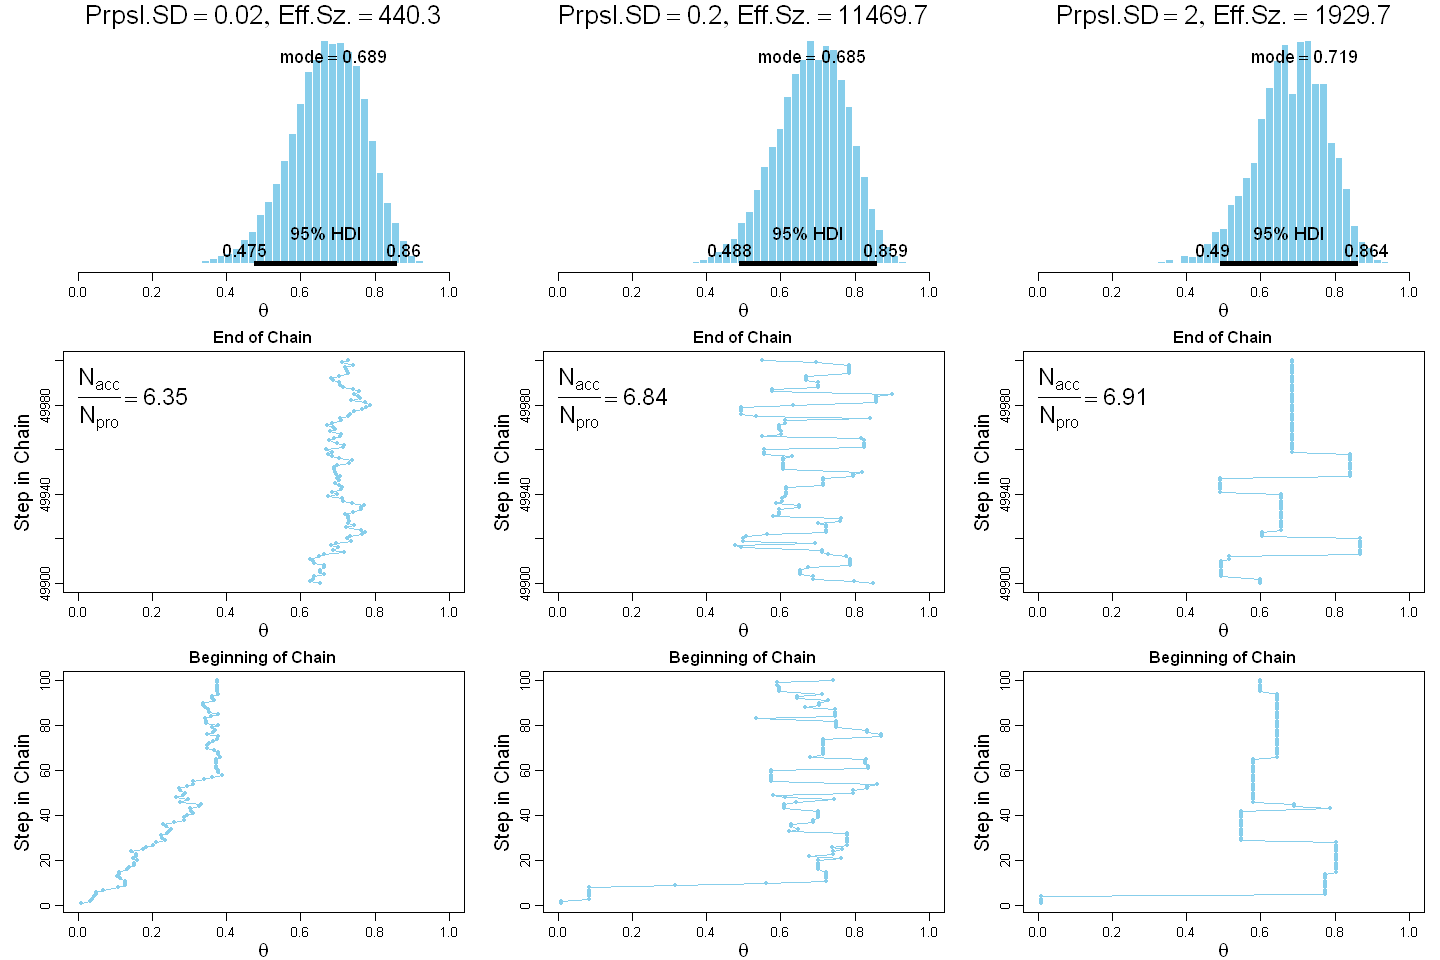

In [30]:
options(repr.plot.width =  12, repr.plot.height = 8)
layout( matrix(1:9,nrow=3) )
par(mar=c(3,4,2,1),mgp=c(2,0.7,0))
for (psd in proposalSD) {
    for ( t in 1:(trajLength-1) ) {
    	currentPosition = trajectory[t]
    	# Use the proposal distribution to generate a proposed jump.
    	proposedJump = rnorm( 1 , mean=0 , sd=psd )
    	# Compute the probability of accepting the proposed jump.
    	probAccept = min( 1,
    		targetRelProb( currentPosition + proposedJump , myData )
    		/ targetRelProb( currentPosition , myData ) )
    	# Generate a random uniform value from the interval [0,1] to
    	# decide whether or not to accept the proposed jump.
    	if ( runif(1) < probAccept ) {
    		# accept the proposed jump
    		trajectory[ t+1 ] = currentPosition + proposedJump
    		# increment the accepted counter, just to monitor performance
    		if ( t > burnIn ) { nAccepted = nAccepted + 1 }
    	} else {
    		# reject the proposed jump, stay at current position
    		trajectory[ t+1 ] = currentPosition
    		# increment the rejected counter, just to monitor performance
    		if ( t > burnIn ) { nRejected = nRejected + 1 }
    	}
    }
    # Extract the post-burnIn portion of the trajectory.
    acceptedTraj = trajectory[ (burnIn+1) : length(trajectory) ]
    
    # End of Metropolis algorithm.
    
    #-----------------------------------------------------------------------
    # Display the chain.
    
    # Posterior histogram:
    paramInfo = plotPost( acceptedTraj , xlim=c(0,1) , xlab=bquote(theta) , 
                          cex.main=2.0 ,
                          main=bquote( list( "Prpsl.SD" == .(psd) ,
                          "Eff.Sz." == .(round(effectiveSize(acceptedTraj),1)) ) ) )
    
    # Trajectory, a.k.a. trace plot, end of chain:
    idxToPlot = (trajLength-100):trajLength
    plot( trajectory[idxToPlot] , idxToPlot , main="End of Chain" ,
          xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
          type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
    # Display proposal SD and acceptance ratio in the plot.
    text( 0.0 , trajLength , adj=c(0.0,1.1) , cex=1.75 ,
          labels = bquote( frac(N[acc],N[pro]) == 
                           .(signif( nAccepted/length(acceptedTraj) , 3 ))))
    
    # Trajectory, a.k.a. trace plot, beginning of chain:
    idxToPlot = 1:100
    plot( trajectory[idxToPlot] , idxToPlot , main="Beginning of Chain" ,
          xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
          type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
    # Indicate burn in limit (might not be visible if not in range):
    if ( burnIn > 0 ) {
      abline(h=burnIn,lty="dotted")
      text( 0.5 , burnIn+1 , "Burn In" , adj=c(0.5,1.1) )
    }
}

As we can see in the figure above, proposal standard deviates that are either too bog or too small result in very low ESS. This is because the jumps that are accepted are either very close to the original jump and provide little new information or the jumps are too big and don't accurately capture the distribution. A proposal distribution in between seems to work the best.

# DBDA Exercise 7.3

## Part (b)

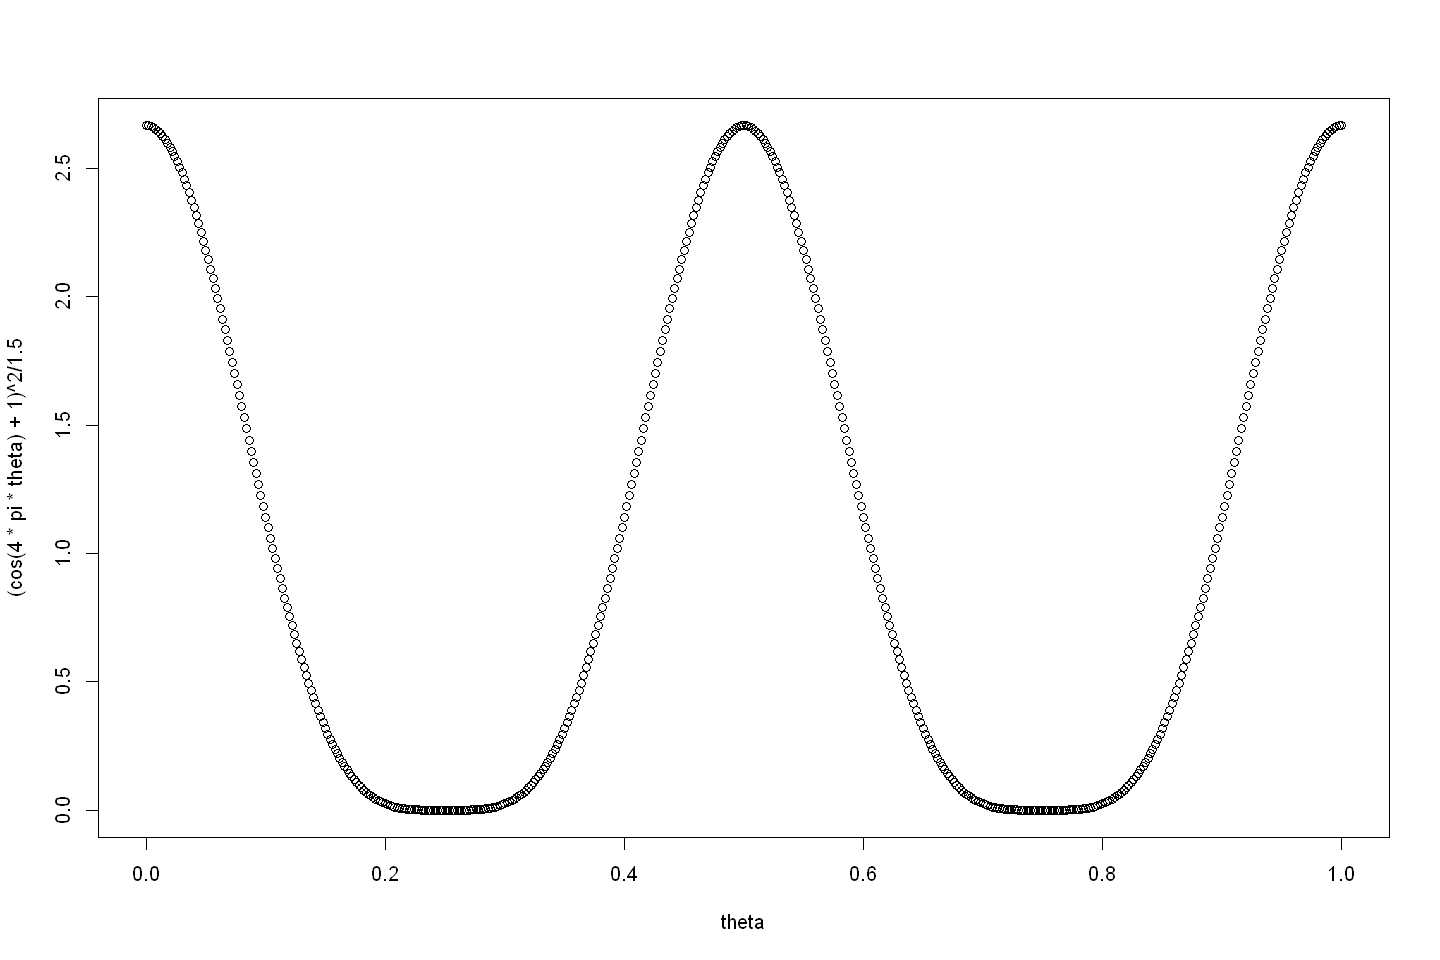

In [32]:
theta = seq(0,1,length=501);
plot(theta , (cos(4*pi*theta)+1)^2/1.5 )

## Part (c)

In [34]:
# Define the prior density function. 
prior = function( theta ) {
  pTheta = (cos(4*pi*theta)+1)^2/1.5
  # The theta values passed into this function are generated at random,
  # and therefore might be inadvertently greater than 1 or less than 0.
  # The prior for theta > 1 or for theta < 0 is zero:
  pTheta[ theta > 1 | theta < 0 ] = 0
  return( pTheta )
}

In [ ]:
myData = c()
proposalSD = c(0.02,0.2,2.0)[2]

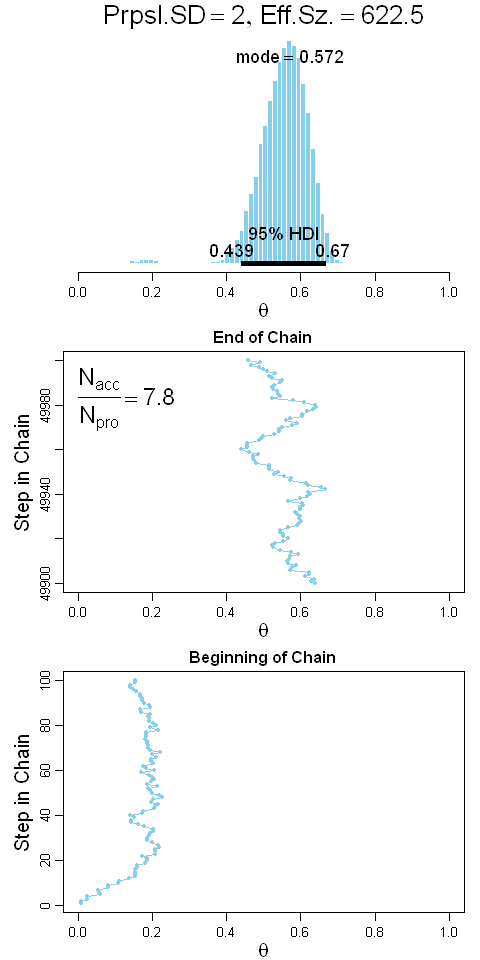

In [35]:
for ( t in 1:(trajLength-1) ) {
    currentPosition = trajectory[t]
    # Use the proposal distribution to generate a proposed jump.
    proposedJump = rnorm( 1 , mean=0 , sd=proposalSD )
    # Compute the probability of accepting the proposed jump.
    probAccept = min( 1,
        targetRelProb( currentPosition + proposedJump , myData )
        / targetRelProb( currentPosition , myData ) )
    # Generate a random uniform value from the interval [0,1] to
    # decide whether or not to accept the proposed jump.
    if ( runif(1) < probAccept ) {
        # accept the proposed jump
        trajectory[ t+1 ] = currentPosition + proposedJump
        # increment the accepted counter, just to monitor performance
        if ( t > burnIn ) { nAccepted = nAccepted + 1 }
    } else {
        # reject the proposed jump, stay at current position
        trajectory[ t+1 ] = currentPosition
        # increment the rejected counter, just to monitor performance
        if ( t > burnIn ) { nRejected = nRejected + 1 }
    }
}
# Extract the post-burnIn portion of the trajectory.
acceptedTraj = trajectory[ (burnIn+1) : length(trajectory) ]

# End of Metropolis algorithm.

#-----------------------------------------------------------------------
# Display the chain.
options(repr.plot.width =  4, repr.plot.height = 8)
layout( matrix(1:3,nrow=3) )
par(mar=c(3,4,2,1),mgp=c(2,0.7,0))
# Posterior histogram:
paramInfo = plotPost( acceptedTraj , xlim=c(0,1) , xlab=bquote(theta) , 
                      cex.main=2.0 ,
                      main=bquote( list( "Prpsl.SD" == .(psd) ,
                      "Eff.Sz." == .(round(effectiveSize(acceptedTraj),1)) ) ) )

# Trajectory, a.k.a. trace plot, end of chain:
idxToPlot = (trajLength-100):trajLength
plot( trajectory[idxToPlot] , idxToPlot , main="End of Chain" ,
      xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
      type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
# Display proposal SD and acceptance ratio in the plot.
text( 0.0 , trajLength , adj=c(0.0,1.1) , cex=1.75 ,
      labels = bquote( frac(N[acc],N[pro]) == 
                       .(signif( nAccepted/length(acceptedTraj) , 3 ))))

# Trajectory, a.k.a. trace plot, beginning of chain:
idxToPlot = 1:100
plot( trajectory[idxToPlot] , idxToPlot , main="Beginning of Chain" ,
      xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
      type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
# Indicate burn in limit (might not be visible if not in range):
if ( burnIn > 0 ) {
  abline(h=burnIn,lty="dotted")
  text( 0.5 , burnIn+1 , "Burn In" , adj=c(0.5,1.1) )
}

The chain only seems to capture the middle peak and does not accurately represent the distribution.

## Part (d)

In [40]:
myData = c()
proposalSD = c(0.02,0.2,2.0)[2]

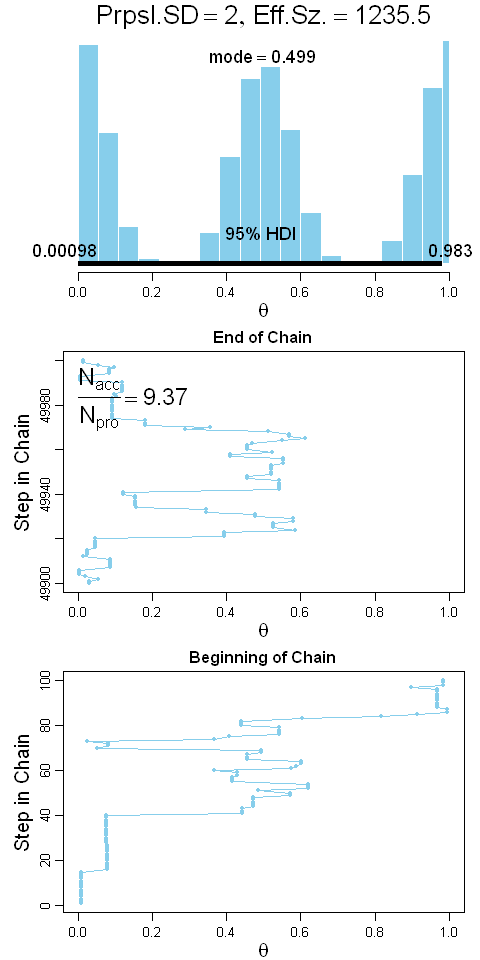

In [41]:
for ( t in 1:(trajLength-1) ) {
    currentPosition = trajectory[t]
    # Use the proposal distribution to generate a proposed jump.
    proposedJump = rnorm( 1 , mean=0 , sd=proposalSD )
    # Compute the probability of accepting the proposed jump.
    probAccept = min( 1,
        targetRelProb( currentPosition + proposedJump , myData )
        / targetRelProb( currentPosition , myData ) )
    # Generate a random uniform value from the interval [0,1] to
    # decide whether or not to accept the proposed jump.
    if ( runif(1) < probAccept ) {
        # accept the proposed jump
        trajectory[ t+1 ] = currentPosition + proposedJump
        # increment the accepted counter, just to monitor performance
        if ( t > burnIn ) { nAccepted = nAccepted + 1 }
    } else {
        # reject the proposed jump, stay at current position
        trajectory[ t+1 ] = currentPosition
        # increment the rejected counter, just to monitor performance
        if ( t > burnIn ) { nRejected = nRejected + 1 }
    }
}
# Extract the post-burnIn portion of the trajectory.
acceptedTraj = trajectory[ (burnIn+1) : length(trajectory) ]

# End of Metropolis algorithm.

#-----------------------------------------------------------------------
# Display the chain.
options(repr.plot.width =  4, repr.plot.height = 8)
layout( matrix(1:3,nrow=3) )
par(mar=c(3,4,2,1),mgp=c(2,0.7,0))
# Posterior histogram:
paramInfo = plotPost( acceptedTraj , xlim=c(0,1) , xlab=bquote(theta) , 
                      cex.main=2.0 ,
                      main=bquote( list( "Prpsl.SD" == .(psd) ,
                      "Eff.Sz." == .(round(effectiveSize(acceptedTraj),1)) ) ) )

# Trajectory, a.k.a. trace plot, end of chain:
idxToPlot = (trajLength-100):trajLength
plot( trajectory[idxToPlot] , idxToPlot , main="End of Chain" ,
      xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
      type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
# Display proposal SD and acceptance ratio in the plot.
text( 0.0 , trajLength , adj=c(0.0,1.1) , cex=1.75 ,
      labels = bquote( frac(N[acc],N[pro]) == 
                       .(signif( nAccepted/length(acceptedTraj) , 3 ))))

# Trajectory, a.k.a. trace plot, beginning of chain:
idxToPlot = 1:100
plot( trajectory[idxToPlot] , idxToPlot , main="Beginning of Chain" ,
      xlab=bquote(theta) , xlim=c(0,1) , ylab="Step in Chain" ,
      type="o" , pch=20 , col="skyblue" , cex.lab=1.5 )
# Indicate burn in limit (might not be visible if not in range):
if ( burnIn > 0 ) {
  abline(h=burnIn,lty="dotted")
  text( 0.5 , burnIn+1 , "Burn In" , adj=c(0.5,1.1) )
}

Now the posterior seems to more accurately the data. This is because the data gives it a push to explore the regions arround 0 and 1 allowing it to spread over a wider range.

# DBDA Exercise 9.3

In [4]:
# Read the data file:
myData = data.frame(y = c(rep(1,30), rep(0,70), rep(1,40), rep(0,60), rep(1,50), rep(0,50), rep(1,60), rep(0,40), rep(1,70), rep(0,30)),
                    s=c(rep("S01",100), rep("S02",100), rep("S03",100), rep("S04",100), rep("S05",100)))
# Load the relevant model functions into R’s working memory:
src("Jags-Ydich-XnomSsubj-MbernBetaOmegaKappa")


*********************************************************************
Kruschke, J. K. (2015). Doing Bayesian Data Analysis, Second Edition:
A Tutorial with R, JAGS, and Stan. Academic Press / Elsevier.
*********************************************************************



Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 500
   Unobserved stochastic nodes: 7
   Total graph size: 1020

Initializing model

Burning in the MCMC chain...
Sampling final MCMC chain...


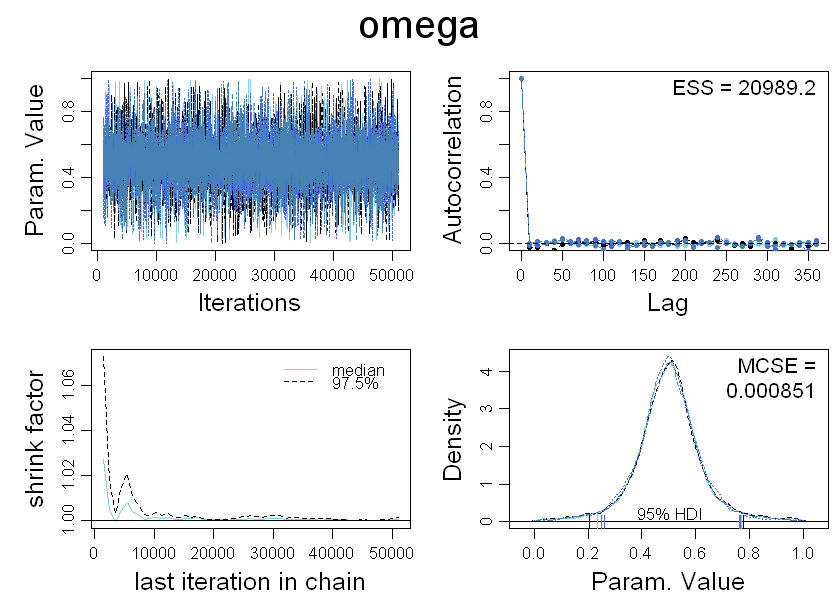

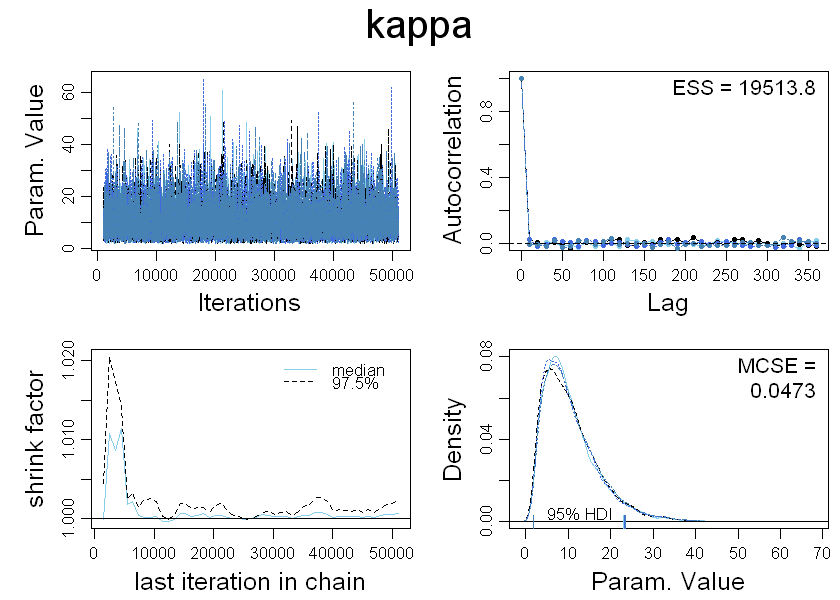

Warning message in plotMCMC(mcmcCoda, data = myData, sName = "s", yName = "y", compVal = 0.5, :
"NAs introduced by coercion"


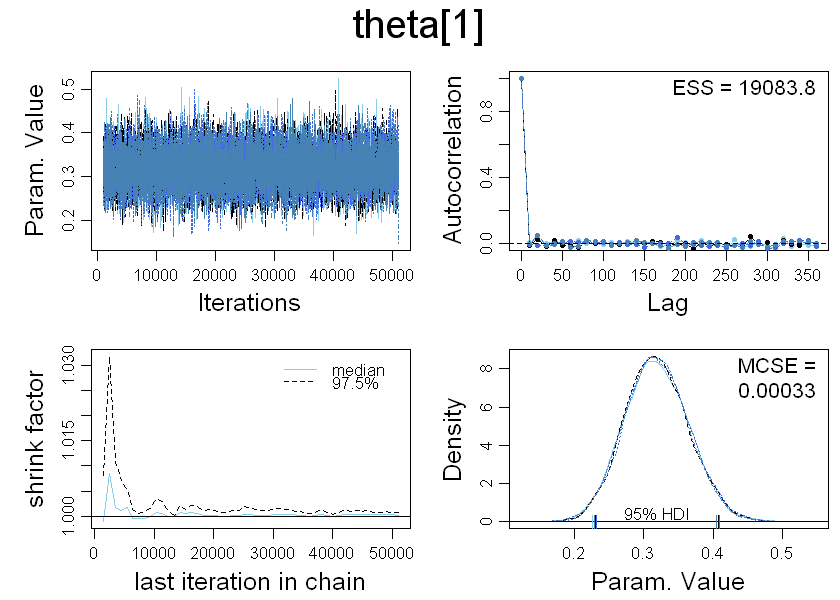

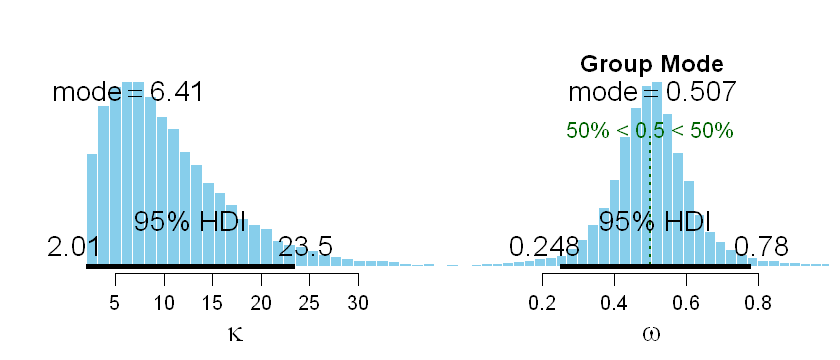

In [5]:
# Generate the MCMC chain:
mcmcCoda = genMCMC( data=myData , sName="s" , yName="y" , numSavedSteps=20000 , thinSteps=10 )
# Display diagnostics of chain, for specified parameters:
diagMCMC( codaObject=mcmcCoda , parName="omega" )
diagMCMC( codaObject=mcmcCoda , parName="kappa" )
diagMCMC( codaObject=mcmcCoda , parName="theta[1]" )
# Get summary statistics of chain:
# smryMCMC( mcmcCoda ,compVal=0.5 , diffIdVec=c(1,14,28), compValDiff=0.0 )
# Display posterior information:
plotMCMC( mcmcCoda , data=myData , sName="s" , yName="y" ,compVal=0.5, compValDiff=0.0 )

Compare these plots to figure 9.12.

![fig912.png](fig912.png)

The MLE estimates give us just one value of $\omega$ and $\kappa$ that outputs the maximum likelihood. The Bayesian analysis described above gives us the distribution for the values of these paramaters which tells us, for example, that $\kappa$ is very widely distributed with a very big 95% HDI. Additionally we get more information about each of the proportions for the subjects (i.e. $\theta_1$) as well, instead of just the updated position for one likelihood distribution.